<a href="https://colab.research.google.com/github/DavidZD5/Mineria-de-datos/blob/main/naming_colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

from google.colab import files
uploaded = files.upload()

Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

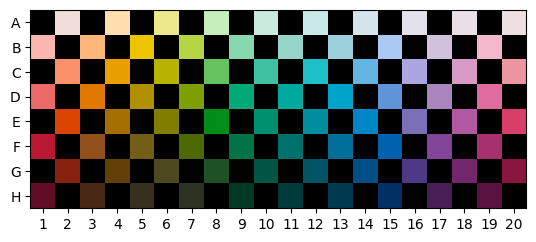

In [3]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

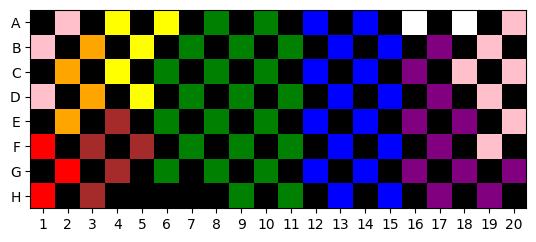

In [4]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [ ]:
# YOUR CODE HERE (add more cells as needed)

# Task
Analyze color naming patterns across English, Spanish, and Tsimane languages. This involves calculating the percentage of color chips named each color for each language, visualizing these percentages using horizontal bar plots, and then investigating the correlation between language pairs (English vs. Tsimane, English vs. Spanish, and Spanish vs. Tsimane) by creating scatter plots from the color naming percentages. The analysis should use the `munsell-array-fixed-choice.csv` dataset.

## Calculate color percentages for each language

### Subtask:
Calculate the percentage of color chips named each color for English, Spanish, and Tsimane languages. This will involve using `value_counts(normalize=True)` on the `english_color`, `spanish_color`, and `tsimane_color` columns of the `df` DataFrame and storing the results as new DataFrames.


**Reasoning**:
To calculate the percentage of each color name for English, Spanish, and Tsimane speakers, I will apply `value_counts(normalize=True)` to the respective color columns, convert the resulting Series to DataFrames, and rename the percentage columns.



In [5]:
english_percentages_df = df['english_color'].value_counts(normalize=True).reset_index()
english_percentages_df.columns = ['Color', 'English_Percentage']

spanish_percentages_df = df['spanish_color'].value_counts(normalize=True).reset_index()
spanish_percentages_df.columns = ['Color', 'Spanish_Percentage']

tsimane_percentages_df = df['tsimane_color'].value_counts(normalize=True).reset_index()
tsimane_percentages_df.columns = ['Color', 'Tsimane_Percentage']

print("English Color Percentages:")
print(english_percentages_df)
print("\nSpanish Color Percentages:")
print(spanish_percentages_df)
print("\nTsimane Color Percentages:")
print(tsimane_percentages_df)

English Color Percentages:
    Color  English_Percentage
0   green              0.2750
1    blue              0.2000
2  purple              0.1375
3    pink              0.1250
4  yellow              0.0625
5   brown              0.0625
6  orange              0.0500
7     red              0.0375
8   black              0.0250
9   white              0.0250

Spanish Color Percentages:
        Color  Spanish_Percentage
0       green              0.2750
1   lightblue              0.1375
2      purple              0.1375
3        pink              0.1000
4       white              0.0750
5         red              0.0500
6      orange              0.0500
7      yellow              0.0500
8       brown              0.0500
9        blue              0.0500
10      black              0.0250

Tsimane Color Percentages:
    Color  Tsimane_Percentage
0   green              0.2500
1    blue              0.1500
2  yellow              0.1375
3  purple              0.1250
4   white              0.1125

**Reasoning**:
The subtask is to visualize the calculated percentages using horizontal bar plots for each language. I will use `matplotlib.pyplot` to create three horizontal bar plots, one for each language's color percentages, ensuring proper labels, titles, and layout for readability.



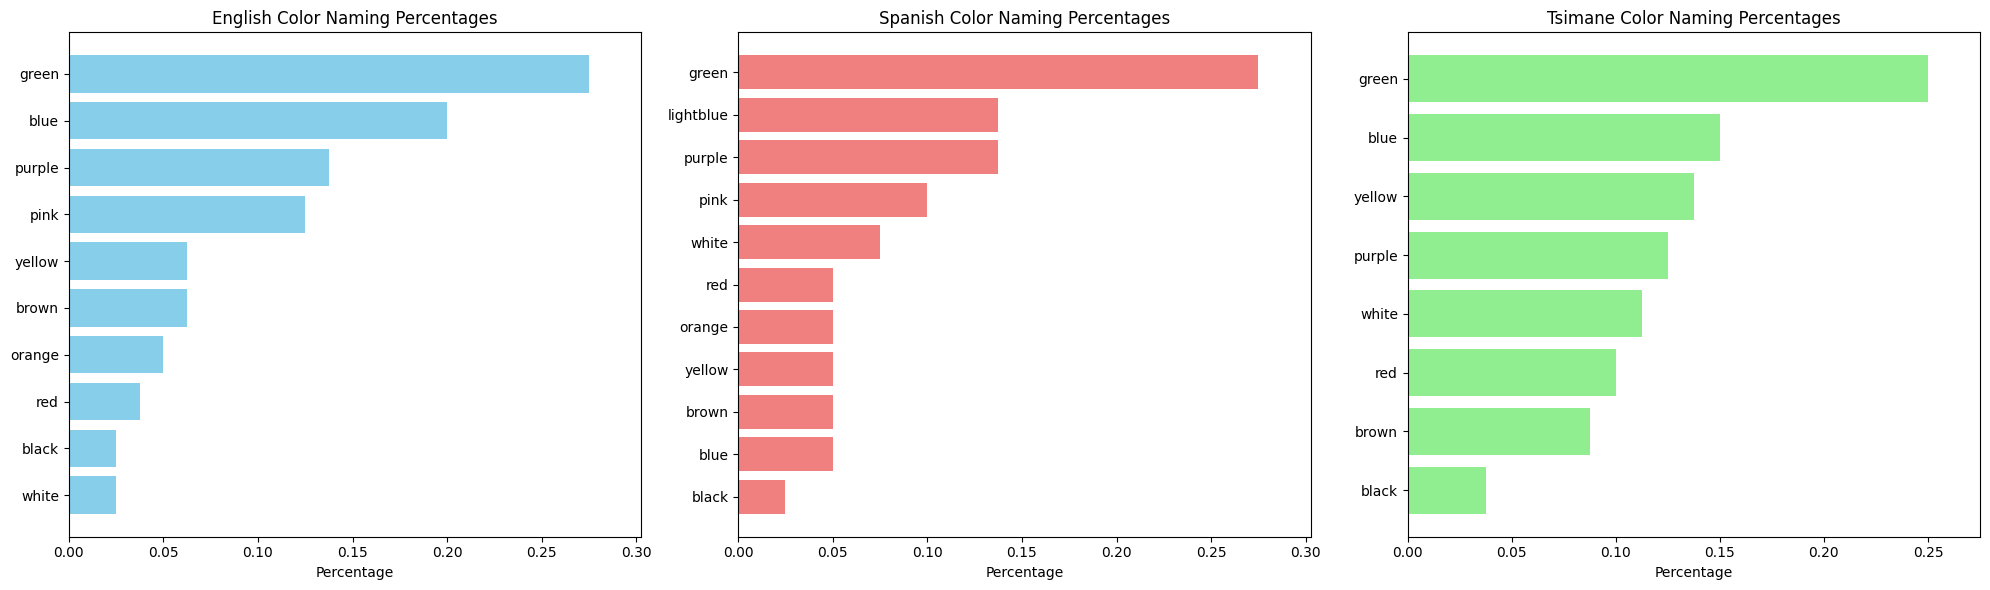

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# English Plot
axes[0].barh(english_percentages_df['Color'], english_percentages_df['English_Percentage'], color='skyblue')
axes[0].set_xlabel('Percentage')
axes[0].set_title('English Color Naming Percentages')
axes[0].set_xlim(0, max(english_percentages_df['English_Percentage']) * 1.1)
axes[0].invert_yaxis() # To have the highest percentage at the top

# Spanish Plot
axes[1].barh(spanish_percentages_df['Color'], spanish_percentages_df['Spanish_Percentage'], color='lightcoral')
axes[1].set_xlabel('Percentage')
axes[1].set_title('Spanish Color Naming Percentages')
axes[1].set_xlim(0, max(spanish_percentages_df['Spanish_Percentage']) * 1.1)
axes[1].invert_yaxis()

# Tsimane Plot
axes[2].barh(tsimane_percentages_df['Color'], tsimane_percentages_df['Tsimane_Percentage'], color='lightgreen')
axes[2].set_xlabel('Percentage')
axes[2].set_title('Tsimane Color Naming Percentages')
axes[2].set_xlim(0, max(tsimane_percentages_df['Tsimane_Percentage']) * 1.1)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

**Reasoning**:
To analyze the correlation between languages, I need to merge the percentage DataFrames. I will start by merging the English and Tsimane percentages, then English and Spanish, and finally Spanish and Tsimane. This will prepare the data for scatter plot visualization.



In [7]:
english_tsimane_correlation_df = pd.merge(english_percentages_df, tsimane_percentages_df, on='Color', how='outer').fillna(0)
english_spanish_correlation_df = pd.merge(english_percentages_df, spanish_percentages_df, on='Color', how='outer').fillna(0)
spanish_tsimane_correlation_df = pd.merge(spanish_percentages_df, tsimane_percentages_df, on='Color', how='outer').fillna(0)

print("English vs Tsimane Correlation Data:\n")
print(english_tsimane_correlation_df)
print("\nEnglish vs Spanish Correlation Data:\n")
print(english_spanish_correlation_df)
print("\nSpanish vs Tsimane Correlation Data:\n")
print(spanish_tsimane_correlation_df)

English vs Tsimane Correlation Data:

    Color  English_Percentage  Tsimane_Percentage
0   black              0.0250              0.0375
1    blue              0.2000              0.1500
2   brown              0.0625              0.0875
3   green              0.2750              0.2500
4  orange              0.0500              0.0000
5    pink              0.1250              0.0000
6  purple              0.1375              0.1250
7     red              0.0375              0.1000
8   white              0.0250              0.1125
9  yellow              0.0625              0.1375

English vs Spanish Correlation Data:

        Color  English_Percentage  Spanish_Percentage
0       black              0.0250              0.0250
1        blue              0.2000              0.0500
2       brown              0.0625              0.0500
3       green              0.2750              0.2750
4   lightblue              0.0000              0.1375
5      orange              0.0500              0.

**Reasoning**:
To visualize the correlation between language pairs, I will create scatter plots for English vs. Tsimane, English vs. Spanish, and Spanish vs. Tsimane percentages, using the merged DataFrames. Each plot will have appropriate labels and titles.



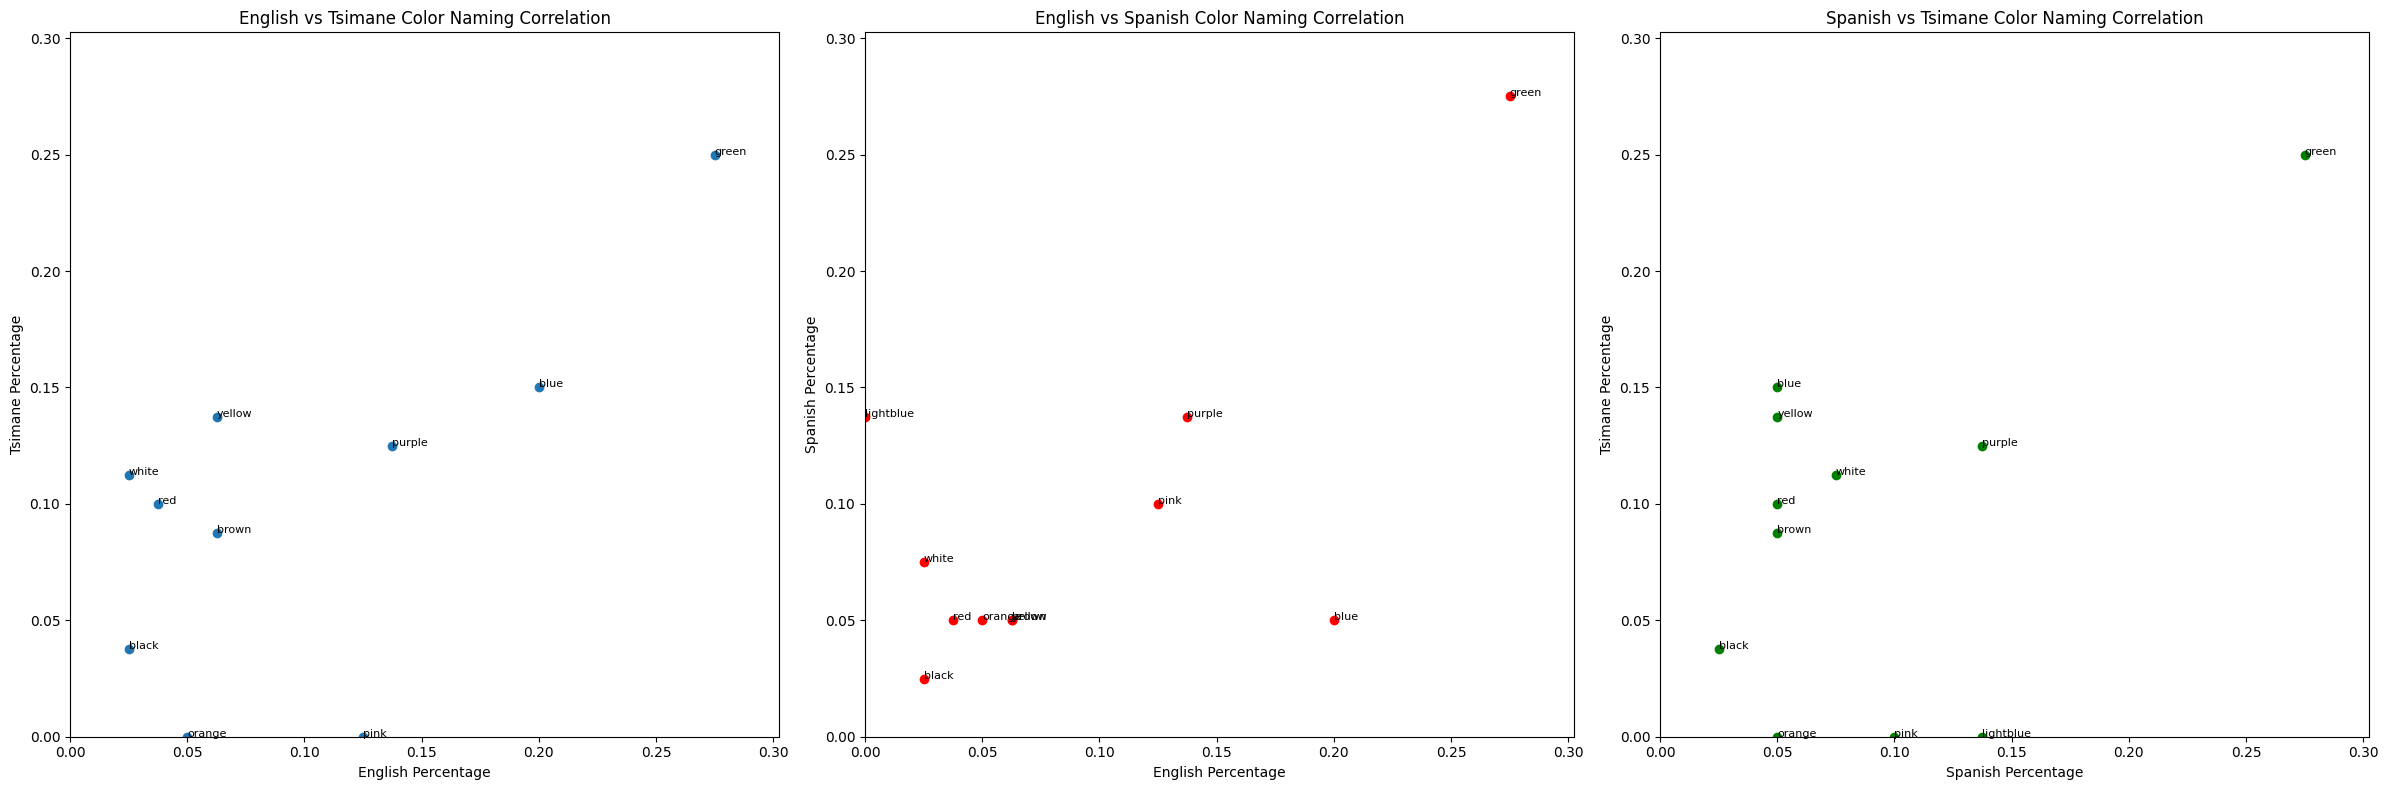

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# English vs Tsimane Scatter Plot
axes[0].scatter(english_tsimane_correlation_df['English_Percentage'], english_tsimane_correlation_df['Tsimane_Percentage'])
for i, txt in enumerate(english_tsimane_correlation_df['Color']):
    axes[0].annotate(txt, (english_tsimane_correlation_df['English_Percentage'][i], english_tsimane_correlation_df['Tsimane_Percentage'][i]), fontsize=8)
axes[0].set_xlabel('English Percentage')
axes[0].set_ylabel('Tsimane Percentage')
axes[0].set_title('English vs Tsimane Color Naming Correlation')
axes[0].set_xlim(0, max(english_tsimane_correlation_df['English_Percentage'].max(), english_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)
axes[0].set_ylim(0, max(english_tsimane_correlation_df['English_Percentage'].max(), english_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)

# English vs Spanish Scatter Plot
axes[1].scatter(english_spanish_correlation_df['English_Percentage'], english_spanish_correlation_df['Spanish_Percentage'], color='red')
for i, txt in enumerate(english_spanish_correlation_df['Color']):
    axes[1].annotate(txt, (english_spanish_correlation_df['English_Percentage'][i], english_spanish_correlation_df['Spanish_Percentage'][i]), fontsize=8)
axes[1].set_xlabel('English Percentage')
axes[1].set_ylabel('Spanish Percentage')
axes[1].set_title('English vs Spanish Color Naming Correlation')
axes[1].set_xlim(0, max(english_spanish_correlation_df['English_Percentage'].max(), english_spanish_correlation_df['Spanish_Percentage'].max()) * 1.1)
axes[1].set_ylim(0, max(english_spanish_correlation_df['English_Percentage'].max(), english_spanish_correlation_df['Spanish_Percentage'].max()) * 1.1)

# Spanish vs Tsimane Scatter Plot
axes[2].scatter(spanish_tsimane_correlation_df['Spanish_Percentage'], spanish_tsimane_correlation_df['Tsimane_Percentage'], color='green')
for i, txt in enumerate(spanish_tsimane_correlation_df['Color']):
    axes[2].annotate(txt, (spanish_tsimane_correlation_df['Spanish_Percentage'][i], spanish_tsimane_correlation_df['Tsimane_Percentage'][i]), fontsize=8)
axes[2].set_xlabel('Spanish Percentage')
axes[2].set_ylabel('Tsimane Percentage')
axes[2].set_title('Spanish vs Tsimane Color Naming Correlation')
axes[2].set_xlim(0, max(spanish_tsimane_correlation_df['Spanish_Percentage'].max(), spanish_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)
axes[2].set_ylim(0, max(spanish_tsimane_correlation_df['Spanish_Percentage'].max(), spanish_tsimane_correlation_df['Tsimane_Percentage'].max()) * 1.1)

plt.tight_layout()
plt.show()
